# 12장 실습 — 혼합 비율의 과학

4부부터 시뮬레이터를 보는 눈을 바꾼다. 지금까지 시뮬은 **정책을 학습시키는 곳**이었다. 이제부터는 **데이터를 만드는 공장**이다.

바뀌는 것은 정책 학습 방식이다. 3부의 강화학습 대신 **모방학습**을 쓴다. 전문가의 시연을 모으고 관측에서 행동으로 가는 사상을 지도학습으로 배운다. VLA 계열이 쓰는 방식이고, 그래서 이 부의 질문이 실무의 질문과 곧바로 겹친다 — **시뮬에서 만든 데이터와 실기에서 모은 데이터를 어떤 비율로 섞을 것인가.**

직관은 대개 1:1을 말한다. 이 노트북은 그 직관이 두 방향으로 틀리는 것을 잰다.

실행 시간은 CPU에서 3분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 두 도메인

시뮬과 실기를 세운다. 앞 장들과 같은 방식인데, 이번에는 차이에 **관측 어긋남**을 하나 더 넣는다.

- 시뮬 — 마찰 0.60, 게인 120, 지연 없음, 잡음 없음, 관측 정확
- 실기 — 마찰 0.75, 게인 100, 지연 1스텝, 관측 잡음 3 mm, 그리고 **블록 위치 관측이 (+15, −10) mm 어긋나 있다**

마지막 항이 이 노트북의 장치다. 실제 시스템에서 늘 생기는 교정 오차를 흉내 낸 것이다 — 카메라 외부 파라미터가 조금 틀렸거나, 마커가 물체 중심에서 벗어나 붙었거나 하면 이렇게 된다. 시뮬에는 이 어긋남이 없다.

전문가는 6장에서 쓴 서보 규칙이고, **참값**을 보고 행동한다. 사람이 모션캡처를 보며 원격조작하는 상황에 해당한다. 그래서 실기 시연은 「어긋난 관측 ↔ 올바른 행동」 짝으로 기록된다. 이것이 나중에 앵커가 된다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SIM = dict(mu=.60, kv=120., lat=0, noise=0., bias=(0., 0.))
REAL = dict(mu=.75, kv=100., lat=1, noise=.003, bias=(.015, -.010))
CACHE = {}


def model_of(mu, kv):
    k = (round(mu, 2), round(kv, 0))
    if k not in CACHE:
        CACHE[k] = mujoco.MjModel.from_xml_string(
            XML.format(mu=k[0], kv=k[1]))
    return CACHE[k]


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def expert(b, p, g):
    # 6장의 서보 규칙. 참값을 보고 행동한다
    dv = unit(g - b)
    if np.linalg.norm(g - b) < .012:
        return np.zeros(2)
    e = (b - dv * .045) - p
    if np.linalg.norm(e) > .013:
        u = 14. * e
        n = np.linalg.norm(u)
        return u / n * .22 if n > .22 else u
    return dv * .22


def rollout(dom, rng, pol=None, keep=False):
    m = model_of(dom["mu"], dom["kv"])
    d = mujoco.MjData(m)
    sub = int(round(1 / 20 / m.opt.timestep))
    bx, by = rng.uniform(-.03, .03, 2)
    d.qpos[0:2] = [bx, by]
    d.qpos[2] = .031
    d.qpos[7:9] = [bx - .09, by]
    mujoco.mj_forward(m, d)
    g = np.array([.30, 0.]) + rng.uniform(-.04, .04, 2)
    buf = [np.zeros(2)] * (dom["lat"] + 1)
    log = []
    for t in range(EP):
        b_true = np.asarray(d.qpos[0:2], float)
        b = b_true + np.asarray(dom["bias"])     # 관측만 어긋난다
        if dom["noise"]:
            b = b + rng.normal(0, dom["noise"], 2)
        o = np.concatenate([g - b, d.qvel[0:2],
                            b - d.qpos[7:9],
                            d.qvel[6:8]]).astype(np.float32) * 10.
        if pol is None:
            a = expert(b_true, np.asarray(d.qpos[7:9], float), g)
        else:
            a = pol(o)
        a = np.clip(a, -AMAX, AMAX)
        if keep:
            log.append((o, a / AMAX))
        buf.append(a)
        d.ctrl[:] = buf[-1 - dom["lat"]]
        for _ in range(sub):
            mujoco.mj_step(m, d)
    ok = np.linalg.norm(d.qpos[0:2] - g) < GOAL_R
    return (ok, log) if keep else ok


def collect(dom, n, seed):
    # 성공한 시연만 모은다
    X, Y = [], []
    rng = np.random.default_rng(seed)
    got = tries = 0
    while got < n and tries < n * 4:
        tries += 1
        ok, log = rollout(dom, rng, keep=True)
        if not ok:
            continue
        got += 1
        for o, a in log:
            X.append(o)
            Y.append(a)
    return np.array(X, np.float32), np.array(Y, np.float32), got

## 데모를 모은다

시뮬 데모는 값이 거의 들지 않는다. 400판을 몇 초에 만든다. 실기 데모는 그렇지 않다 — 사람이 붙어 있어야 하고, 물체를 제자리에 돌려놓아야 하고, 하드웨어가 닳는다. 그래서 **20판**만 있다고 치자.

이 비대칭이 4부 전체의 전제다.

In [4]:
t0 = time.time()
Xs, Ys, ns_ep = collect(SIM, 400, 1)
Xr, Yr, nr_ep = collect(REAL, 20, 2)
exp_sim = np.mean([rollout(SIM, np.random.default_rng(i))
                   for i in range(60)])
exp_real = np.mean([rollout(REAL, np.random.default_rng(i))
                    for i in range(60)])

print(pad("", 12) + pad("시연 판수", 12, True)
      + pad("샘플", 12, True) + pad("전문가 성공률", 16, True))
print(pad("시뮬", 12) + pad(ns_ep, 12, True)
      + pad(f"{len(Xs):,}", 12, True)
      + pad(f"{exp_sim:.2f}", 16, True))
print(pad("실기", 12) + pad(nr_ep, 12, True)
      + pad(f"{len(Xr):,}", 12, True)
      + pad(f"{exp_real:.2f}", 16, True))
print(f"\n모으는 데 걸린 시간 {time.time()-t0:.0f}s")

               시연 판수        샘플   전문가 성공률
시뮬                 400      44,000            1.00
실기                  20       2,200            0.90

모으는 데 걸린 시간 8s


## 모방학습기

은닉 64짜리 두 층 MLP에 평균제곱오차다. 정책 구조는 이 노트북의 관심사가 아니다 — 바꿀 것은 **무엇을 먹이느냐** 하나뿐이다.

학습 표본 수를 20,000개로 고정하고, 그중 시뮬에서 뽑는 비율 ρ를 바꾼다. ρ = 0.99면 실기 표본이 200개, 곧 두 판 남짓이다.

In [5]:
class BC(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


def train_bc(X, Y, seed=0, epochs=60):
    torch.manual_seed(seed)
    net = BC()
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    X, Y = torch.from_numpy(X), torch.from_numpy(Y)
    n = len(X)
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 256):
            j = idx[k:k + 256]
            loss = ((net(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return net


def evaluate(net, dom, n=120, seed=999):
    rng = np.random.default_rng(seed)

    def pol(o):
        with torch.no_grad():
            return net(torch.from_numpy(o)).numpy() * AMAX
    return float(np.mean([rollout(dom, rng, pol=pol)
                          for _ in range(n)]))


def mixture(rho, T=20_000, kr=None, seed=7):
    # 시뮬에서 rho, 실기에서 1-rho 만큼 뽑아 섞는다
    Xk, Yk = ((Xr, Yr) if kr is None
              else (Xr[:kr * EP], Yr[:kr * EP]))
    ns = int(round(T * rho))
    nr = T - ns
    rng = np.random.default_rng(seed)
    parts = []
    if ns:
        i = rng.integers(0, len(Xs), ns)
        parts.append((Xs[i], Ys[i]))
    if nr:
        i = rng.integers(0, len(Xk), nr)
        parts.append((Xk[i], Yk[i]))
    X = np.concatenate([p[0] for p in parts])
    Y = np.concatenate([p[1] for p in parts])
    return train_bc(X, Y), nr

## 비율을 훑는다

In [6]:
RHOS = (0., .5, .8, .9, .95, .99, 1.)
rows = []
t0 = time.time()
for rho in RHOS:
    net, nr = mixture(rho)
    rows.append((rho, nr, evaluate(net, SIM), evaluate(net, REAL)))
    print(f"ρ = {rho:<5} 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("시뮬 비율 ρ", 14) + pad("실기 표본", 12, True)
      + pad("시뮬 성공률", 14, True) + pad("실기 성공률", 14, True))
for rho, nr, s, r in rows:
    print(pad(f"{rho:g}", 14) + pad(f"{nr:,}", 12, True)
          + pad(f"{s:.2f}", 14, True) + pad(f"{r:.2f}", 14, True))

ρ = 0.0   끝  (11s)


ρ = 0.5   끝  (20s)


ρ = 0.8   끝  (30s)


ρ = 0.9   끝  (40s)


ρ = 0.95  끝  (50s)


ρ = 0.99  끝  (60s)


ρ = 1.0   끝  (70s)

시뮬 비율 ρ      실기 표본   시뮬 성공률   실기 성공률
0                   20,000          0.03          0.70
0.5                 10,000          0.28          0.93
0.8                  4,000          0.02          0.38
0.9                  2,000          0.01          0.17
0.95                 1,000          0.02          0.03
0.99                   200          0.03          0.07
1                        0          0.47          0.00


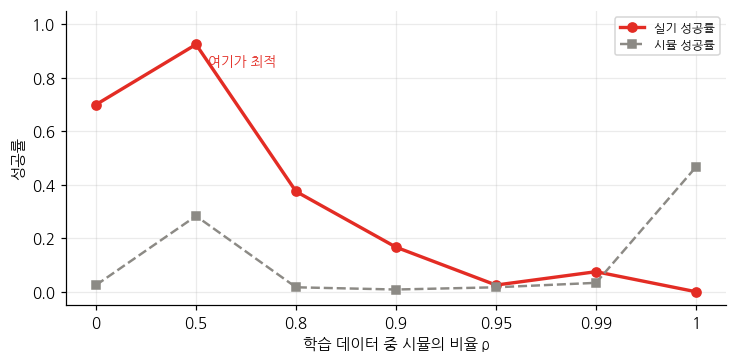

In [7]:
xs = np.arange(len(RHOS))
sim = [r[2] for r in rows]
rea = [r[3] for r in rows]
fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.plot(xs, rea, "o-", color=RED, lw=2.2, ms=6, label="실기 성공률")
ax.plot(xs, sim, "s--", color=GREY, lw=1.6, ms=5,
        label="시뮬 성공률")
best = int(np.argmax(rea))
ax.annotate("여기가 최적", (best, rea[best]), fontsize=9, color=RED,
            xytext=(8, -14), textcoords="offset points")
ax.set_xticks(xs)
ax.set_xticklabels([f"{r:g}" for r in RHOS])
ax.set_xlabel("학습 데이터 중 시뮬의 비율 ρ")
ax.set_ylabel("성공률")
ax.set_ylim(-.05, 1.05)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 시뮬로 채점하면 정확히 거꾸로 고른다

위 표에는 한 열이 더 있다. 같은 정책들을 **시뮬에서** 채점한 회색 선이다.

In [8]:
i_sim = int(np.argmax(sim))
i_real = int(np.argmax(rea))
print(f"시뮬 점수가 고르는 비율  ρ = {RHOS[i_sim]:g}"
      f"  (그 정책의 실기 성공률 {rea[i_sim]:.2f})")
print(f"실기 점수가 고르는 비율  ρ = {RHOS[i_real]:g}"
      f"  (그 정책의 실기 성공률 {rea[i_real]:.2f})")
print()
print(f"두 점수의 Pearson r = {np.corrcoef(sim, rea)[0, 1]:.3f}")

시뮬 점수가 고르는 비율  ρ = 1  (그 정책의 실기 성공률 0.00)
실기 점수가 고르는 비율  ρ = 0.5  (그 정책의 실기 성공률 0.93)

두 점수의 Pearson r = 0.038


## 앵커는 얼마나 필요한가

실기 데이터가 「맞추는」 일을 한다면, 얼마나 있어야 맞춰지는가. 비율은 최적값에 고정하고 실기 시연 판수만 줄여 본다.

In [9]:
t0 = time.time()
anc = []
for k in (1, 2, 5, 10, 20):
    net, _ = mixture(RHOS[i_real], kr=k)
    anc.append((k, evaluate(net, REAL)))
    print(f"실기 {k}판 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("실기 시연", 12) + pad("샘플", 10, True)
      + pad("실기 성공률", 14, True))
for k, v in anc:
    print(pad(f"{k}판", 12) + pad(f"{k*EP:,}", 10, True)
          + pad(f"{v:.2f}", 14, True))

실기 1판 끝  (6s)


실기 2판 끝  (13s)


실기 5판 끝  (19s)


실기 10판 끝  (25s)


실기 20판 끝  (32s)

실기 시연         샘플   실기 성공률
1판                110          0.15
2판                220          0.12
5판                550          0.34
10판             1,100          0.27
20판             2,200          0.93


## 정리

**시뮬과 실기 데이터는 서로 다른 일을 한다.** 시뮬은 상태 공간을 넓게 덮고, 실기는 어긋남을 맞춘다. 그래서 한쪽만으로는 양쪽 끝에서 각각 다른 이유로 무너진다.

**시뮬만으로는 0이다.** 시뮬 데모에는 실기의 관측 어긋남이 없으니 정책이 1.5 cm 옆을 겨냥하게 된다. 성공 반경이 3 cm인 과제에서 그것으로 끝난다.

**실기만으로도 부족하다.** 시연 스무 판은 상태 공간을 덮지 못하고, 정책이 시연에서 벗어나는 순간 오차가 누적된다.

**시뮬 점수는 혼합 비율을 고르는 데 쓸 수 없다.** 시뮬에서 채점하면 실기 성적이 0인 정책을 고른다. 비율은 실기에서 채점해야 정해진다.

**앵커는 생각보다 많이 필요하다.** 한두 판은 없는 것과 비슷했고, 스무 판에서야 제 성능이 나왔다. 실기 데이터가 고치는 것은 상수 하나가 아니라 사상 전체이기 때문이다.

다음 장은 시뮬 쪽 데이터의 질을 다룬다. 넓게 덮는 것이 시뮬의 일이라면, 그 덮개가 실기와 너무 달라 보일 때 무엇을 할 수 있는가 — 생성 모델이 들어오는 자리다.